# A few qualiative tests for finding the cicles
In this notebook, I'm going to just quickly try out a few techniques to get an idea of possible appoaches. I'll take a test image and run various circle finders over it and visualise the results on the circles.

## Test Image
We are going to use `images/custom/davids/high/B/custom_davids_high_B_3.jpg` from the dataset as our test image. It has a few interesting confuser objects and there is grain on the table which we will need to account for. Note that we will most likely be overfitting our solution to this image but dealing with that is what the larger run is about. Here we are just trying techniques out to get a idea of next steps.

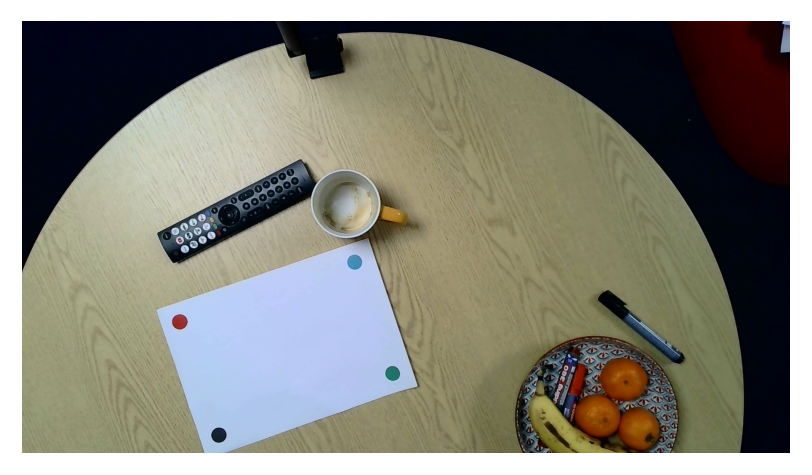

In [1]:
# load in the image
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np


def show(image: np.array, dpi: int = 220, scale: float = 0.4, show_axis=False):
    """show the numpy array as an image using matplotlib

    The figure is scaled to the size of the image at dpi.

    Args:
        image (np.array): The image to display. Assumed to be (h,w,c).
        dpi (int): the dots per inch of the display. Defaults to the dpi of a macbook
        scale (float): scale the image so it will fit nicely in the notebook
    """
    h, w = image.shape[:2]
    figsise = ((w / dpi) * scale, (h / dpi) * scale)
    fig = plt.figure(figsize=figsise, dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])  # fill entire figure
    ax.imshow(image)
    if not show_axis:
        plt.axis("off")
    plt.show()


test_image_path = "../../images/custom/davids/high/B/custom_davids_high_B_3.jpg"
image_bgr = cv.imread(test_image_path)  # note that the
show(cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB), scale=0.4)

## Some transforms
Let's visualise some of the tranformations that were are going to do. Note that we want to limit the number of allocation and copy operations for performance reasons. 

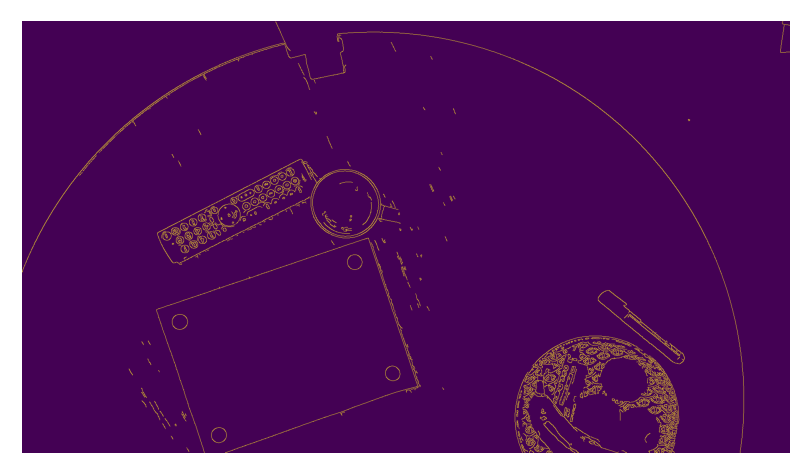

In [2]:
import numpy as np

image_gray = cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)
image_blurred = cv.GaussianBlur(image_gray, (3, 3), 0)


# compute the canny parameters using the "auto-canny" trick
# https://pyimagesearch.com/2015/04/06/zero-parameter-automatic-canny-edge-detection-with-python-and-opencv/
def auto_canny(image, sigma=0.33):
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edged = cv.Canny(image, lower, upper)
    return edged


edges = auto_canny(image_blurred)

show(edges, scale=0.4)

## Test Function
A circle detector is a function that take in an image and outputs a list of cicles coordinates (centre points).
Let's write a function that takes in a circle detector, where the cicles should be, and prints out the results and the length of time it takes to run the detector.

```
CircleDetector = np.array -> [(x0,y0)...(xn,yn)]
```